In [45]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.arima.model import ARIMA
from arch import arch_model
from time import time
from datetime import timedelta

### Parameters

In [2]:
coins = ['BTC-USD', 'ETH-USD']

start_date = '2023-11-01'
end_date = '2024-11-01'

initial_capital = 1000

### Download

In [3]:
all_data = {}
for coin in coins:
    data = yf.download(coin, start=start_date, end=end_date, interval='1h')
    all_data[coin] = data

resampled_data = {}
for coin in all_data.keys():
    data = all_data[coin]
    data.columns = data.columns.get_level_values(0)
    data_4h = data.resample('4H').agg({
        'Open': 'first',
        'High': 'max',
        'Low': 'min',
        'Close': 'last',
        'Volume': 'sum'
    }).dropna()
    resampled_data[coin] = data_4h

for coin in all_data.keys():
    all_data[coin] = resampled_data[coin].dropna()

Index = None
for coin in all_data.keys():
    Index = all_data[coin].index

Index = Index.dropna()

x = {coin: data['Close'].values for coin, data in all_data.items()}
all_data_df = pd.DataFrame(x, index=Index)

[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
<ipython-input-3-614a698c9ab9>:10: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  data_4h = data.resample('4H').agg({


### Stationarity

In [4]:
for column in all_data_df.columns:
    res = adfuller(all_data_df[column])
    print(f"ADF Statistics: {res[0]}\tP-value: {res[1]}")
    if res[1] < 0.1:
        print("Stationary")
    else:
        print("Not Stationary")

ADF Statistics: -1.8501731276007045	P-value: 0.35585169822248963
Not Stationary
ADF Statistics: -1.972727119366226	P-value: 0.2986578201948006
Not Stationary


### First Difference

ADF Statistics: -10.709981671065789	P-value: 3.351160185406004e-19
Stationary
ADF Statistics: -19.98071066834962	P-value: 0.0
Stationary


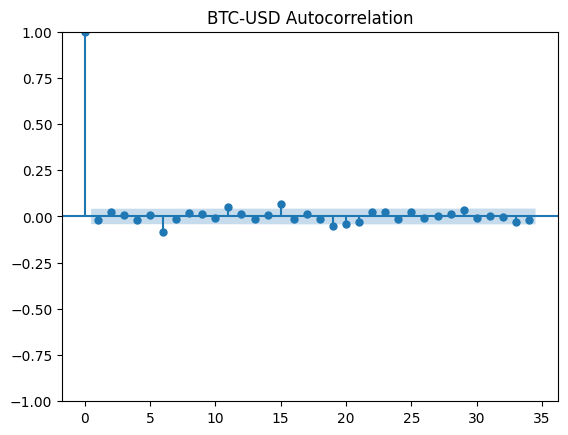

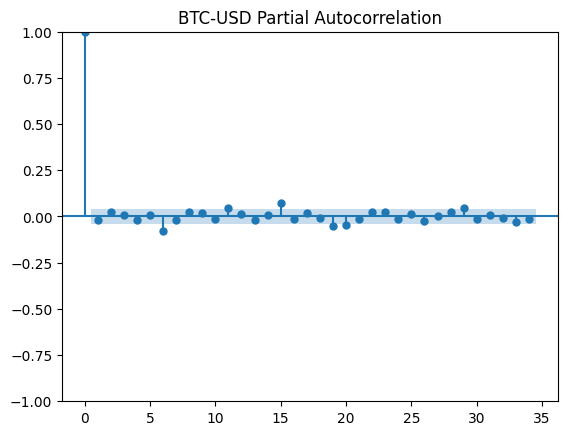

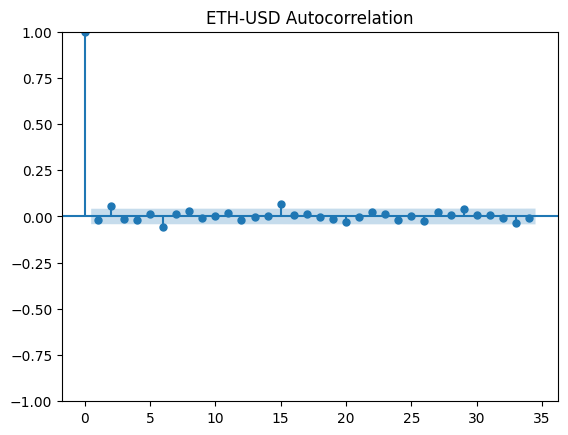

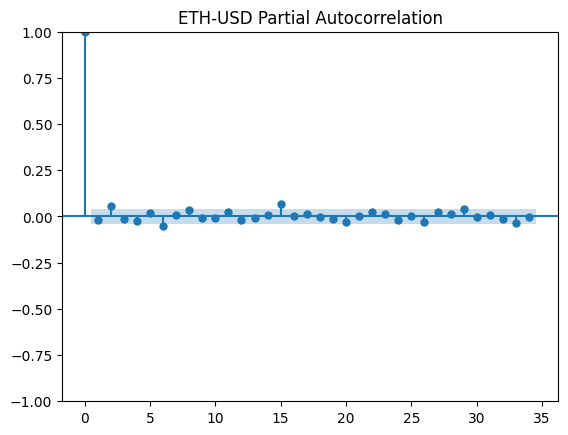

In [5]:
first_diff_df = all_data_df.diff(1)[1:]

for column in first_diff_df.columns:
    res = adfuller(first_diff_df[column])
    print(f"ADF Statistics: {res[0]}\tP-value: {res[1]}")
    if res[1] < 0.1:
        print("Stationary")
    else:
        print("Not Stationary")
    plot_acf(first_diff_df[column], title=f"{column} Autocorrelation")
    plot_pacf(first_diff_df[column], title=f"{column} Partial Autocorrelation")

### Data Split

In [6]:
first_diff_df_train = first_diff_df[:'2024-08-31']
first_diff_df_test = first_diff_df['2024-09-01':'2024-09-30']
first_diff_df_val = first_diff_df['2024-10-01':]

print(first_diff_df_train.shape)
print(first_diff_df_test.shape)
print(first_diff_df_val.shape)

(1829, 2)
(180, 2)
(186, 2)


### Fit Model

In [52]:
orders = {"BTC-USD": (6, 0, 6), "ETH-USD": (2, 0, 2)}

In [76]:
def backtest_arma(order: tuple, prices:pd.DataFrame, all_data:pd.DataFrame, val_data:pd.DataFrame, initial_capital:float):
    Index = val_data.index
    equity = pd.Series(index=Index)
    predictions = pd.Series(index=Index)

    balance = initial_capital
    position = 0

    for datetime in Index:
        model = ARIMA(all_data[:datetime-timedelta(hours = 4)], order=order)
        model_fitted = model.fit()

        pred = model_fitted.predict(datetime)   # predict first difference
        predictions.loc[datetime] = pred.loc[datetime]  # record predicted value

        pred_v = pred[0]
        if position == 0 and pred_v > 0:   # not in position and ascending
            position = balance / prices[datetime-timedelta(hours = 4)]
            balance = 0
    
        elif position != 0 and pred_v < 0: # in buy position and descending
            balance = position * prices[datetime-timedelta(hours = 4)]
            position = 0
            
        equity.loc[datetime] = balance + position * prices[datetime-timedelta(hours = 4)]
        
    print(f"Profit: {equity[-1] - equity[0]}")
    return equity, predictions

### Plot Backtests Results

In [74]:
def plot_backtest(coin, predictions, equities):
    plt.figure(figsize=(14, 7))
    plt.plot(all_data_df[coin], label=f'{coin} Price', color="black")
    plt.legend()
    plt.title('Price: Trading Strategy')
    plt.show()

    plt.figure()
    plt.plot(predictions[coin], label=f'{coin} Prediction', color="red")
    plt.legend()
    plt.title('Predictions: Trading Strategy')
    plt.show()

    plt.figure(figsize=(14, 7))
    plt.plot(equities[coin], label='Portfolio Value', color="green", linestyle='--')
    plt.legend()
    plt.title('Equity: Trading Strategy')
    plt.show()

/usr/local/lib/python3.10/dist-packages/statsmodels/tsa/statespace/sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'
/usr/local/lib/python3.10/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
<ipython-input-76-064de21554ee>:17: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  pred_v = pred[0]
/usr/local/lib/python3.10/dist-packages/statsmodels/tsa/statespace/sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'
/usr/local/lib/python3.10/dis

Profit: 12.026809850214704
Total Time:  2822.363731622696


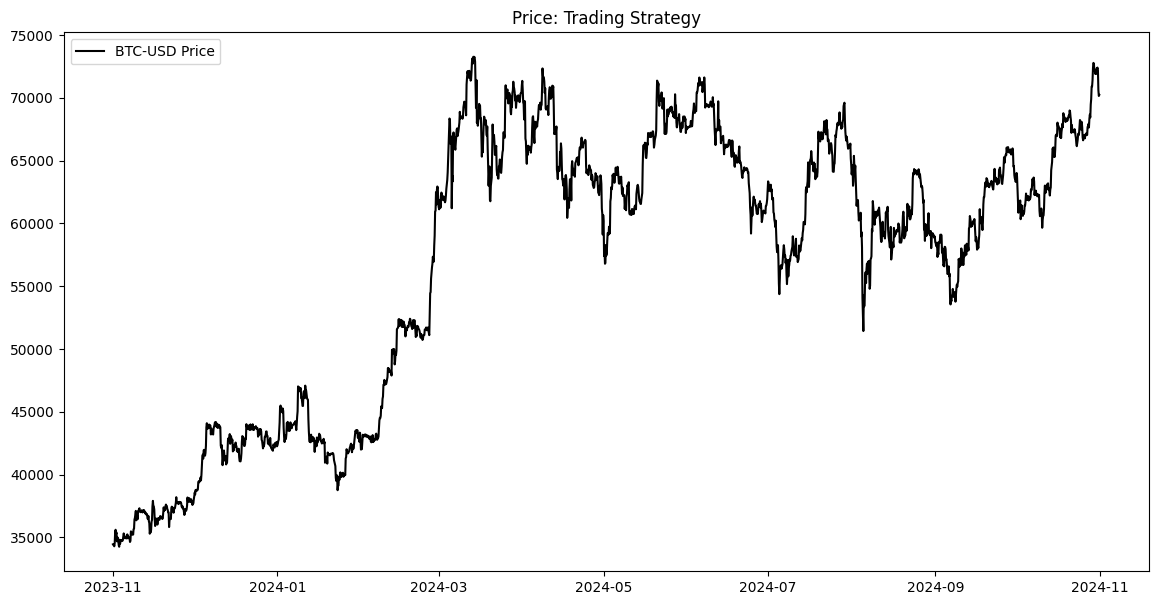

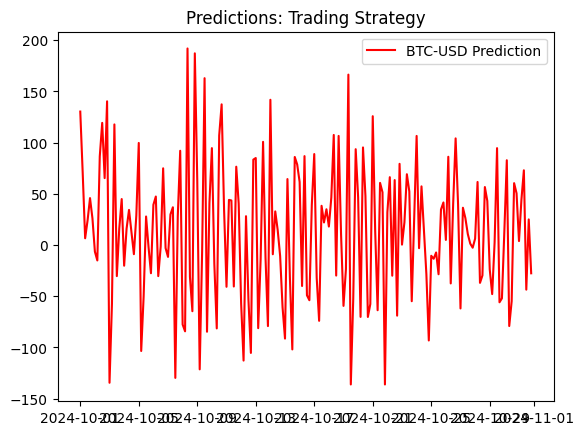

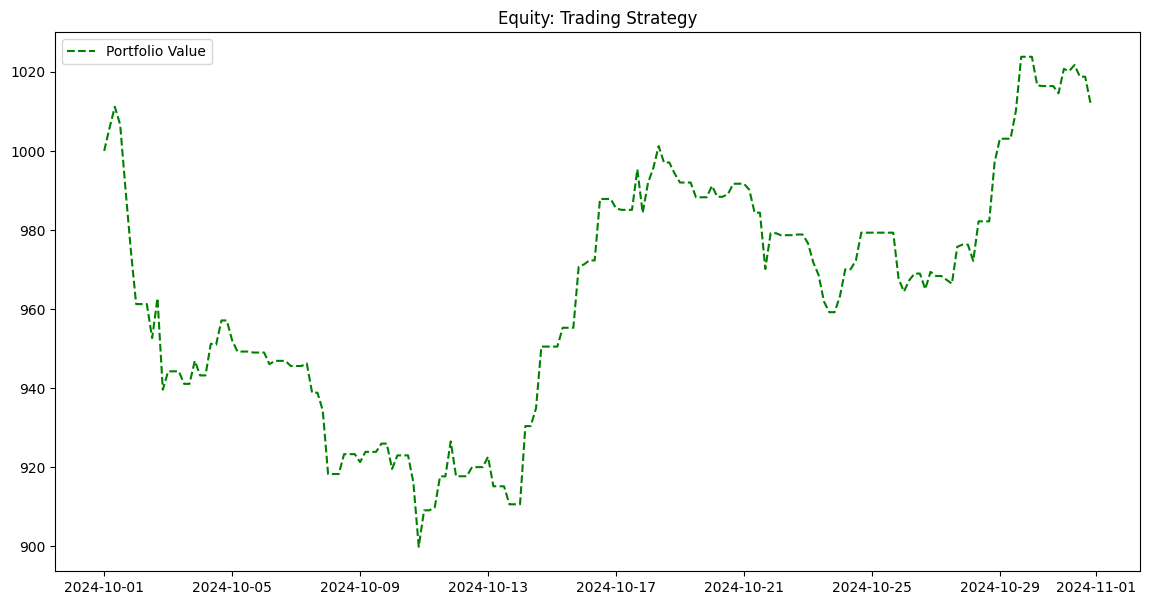

<ipython-input-76-064de21554ee>:17: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  pred_v = pred[0]
<ipython-input-76-064de21554ee>:17: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  pred_v = pred[0]
<ipython-input-76-064de21554ee>:17: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  pred_v = pred[0]
<ipython-input-76-064de21554ee>:17: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, intege

Profit: 44.95754566905839
Total Time:  703.0440287590027


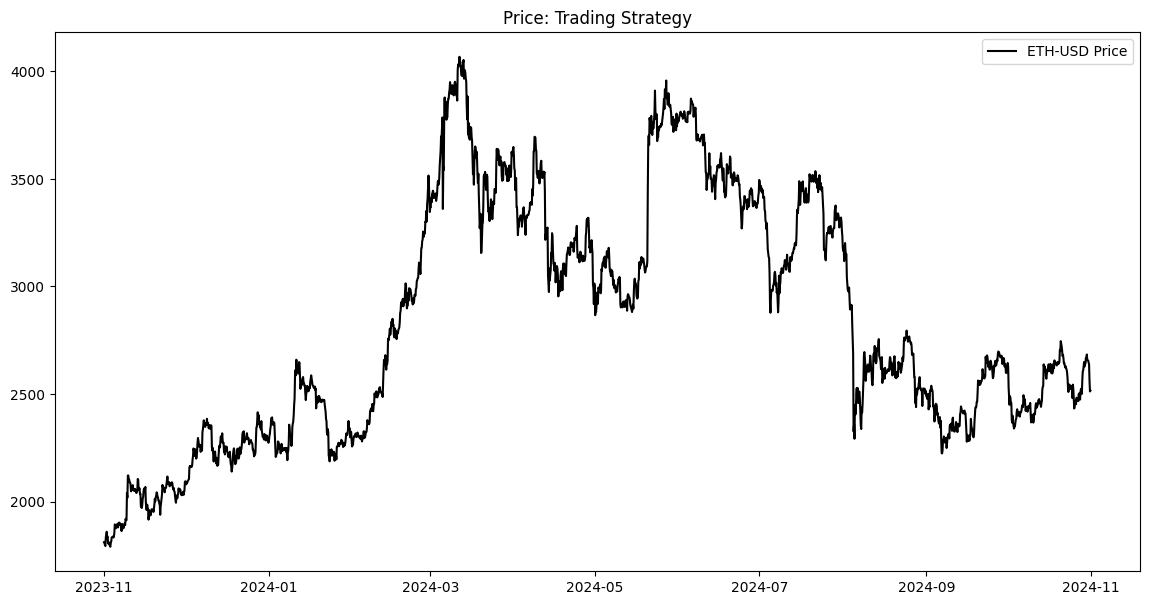

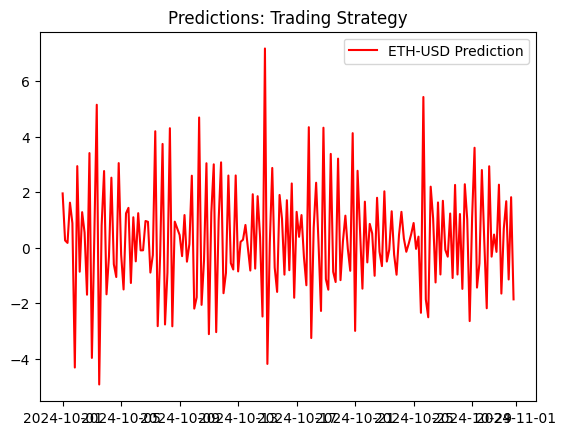

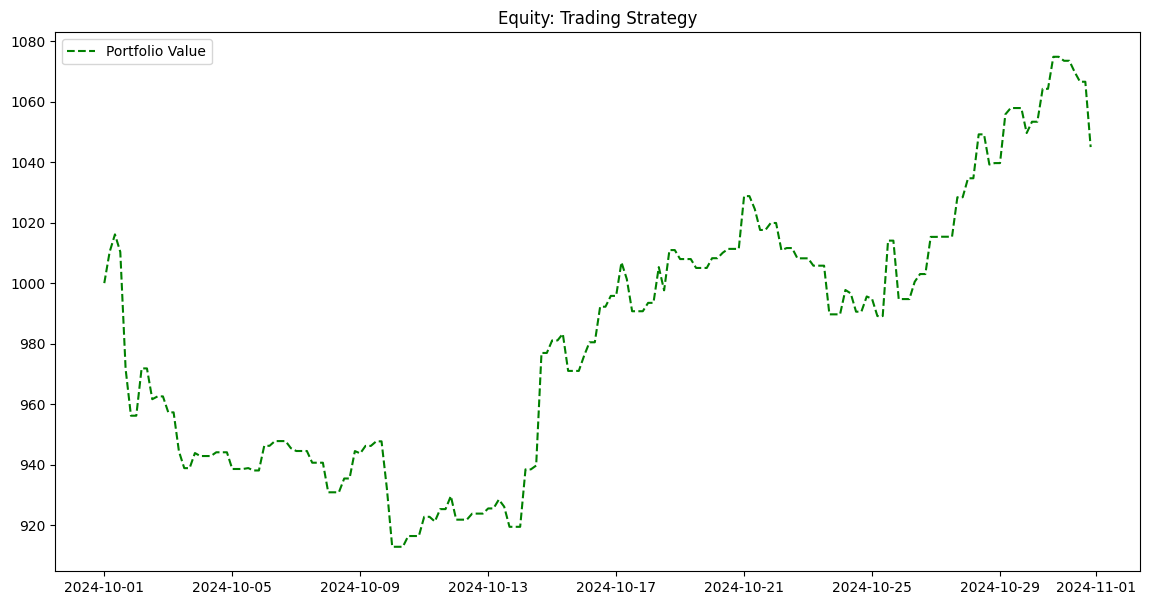

In [77]:
equities_org = {}
predictions_org = {}
for column in first_diff_df.columns:
    start = time()
    equity, prediction = backtest_arma(orders[column], all_data_df[column], first_diff_df[column], first_diff_df_val[column], initial_capital=initial_capital)
    end = time()
    print("Total Time: ", end - start)
    equities_org[column] = equity
    predictions_org[column] = prediction
    plot_backtest(column, predictions_org, equities_org)

### Parameters

### BTC Here

/usr/local/lib/python3.10/dist-packages/statsmodels/tsa/statespace/sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'
/usr/local/lib/python3.10/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
<ipython-input-8-8452052f3ea9>:17: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  pred_v = pred[0]
/usr/local/lib/python3.10/dist-packages/statsmodels/tsa/statespace/sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'


equity:  1000.0


/usr/local/lib/python3.10/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
<ipython-input-8-8452052f3ea9>:17: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  pred_v = pred[0]
/usr/local/lib/python3.10/dist-packages/statsmodels/tsa/statespace/sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'


equity:  1000.0


/usr/local/lib/python3.10/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
<ipython-input-8-8452052f3ea9>:17: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  pred_v = pred[0]
/usr/local/lib/python3.10/dist-packages/statsmodels/tsa/statespace/sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'


...

equity:  1083.6006821469148


/usr/local/lib/python3.10/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
<ipython-input-8-8452052f3ea9>:17: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  pred_v = pred[0]
/usr/local/lib/python3.10/dist-packages/statsmodels/tsa/statespace/sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'


equity:  1079.0408685703503


/usr/local/lib/python3.10/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
<ipython-input-8-8452052f3ea9>:17: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  pred_v = pred[0]
<ipython-input-8-8452052f3ea9>:31: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  print(f"Profit: {equity[-1] - equity[0]}")


equity:  1079.0919773011792
Profit: 79.09197730117921
Total Time:  2463.260368824005


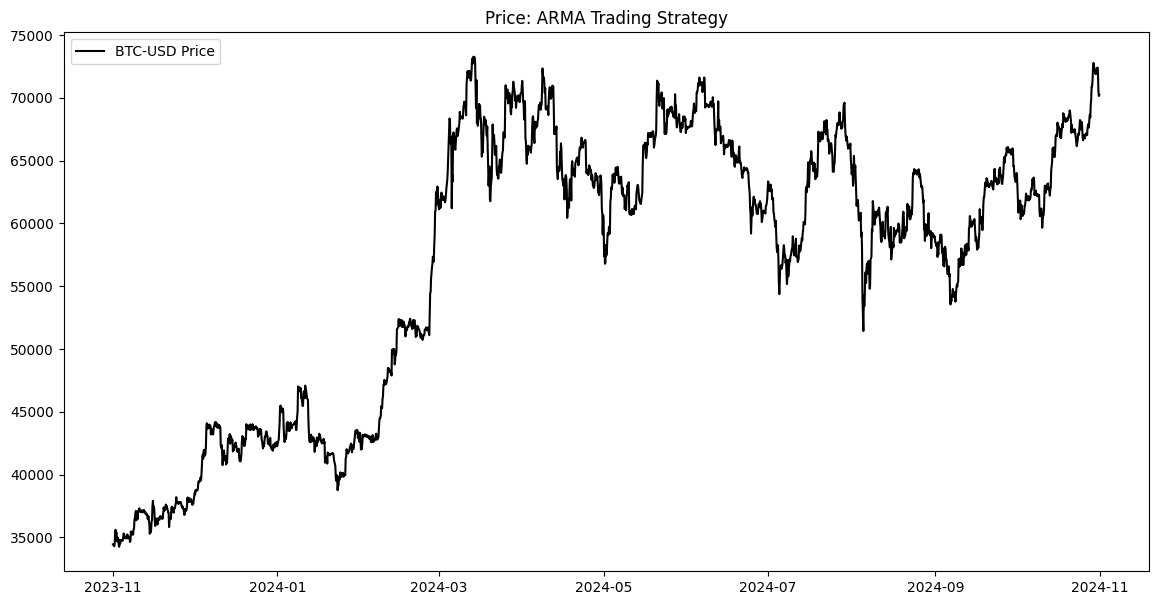

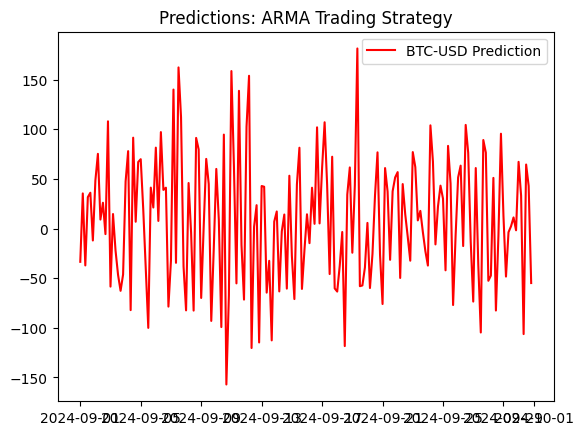

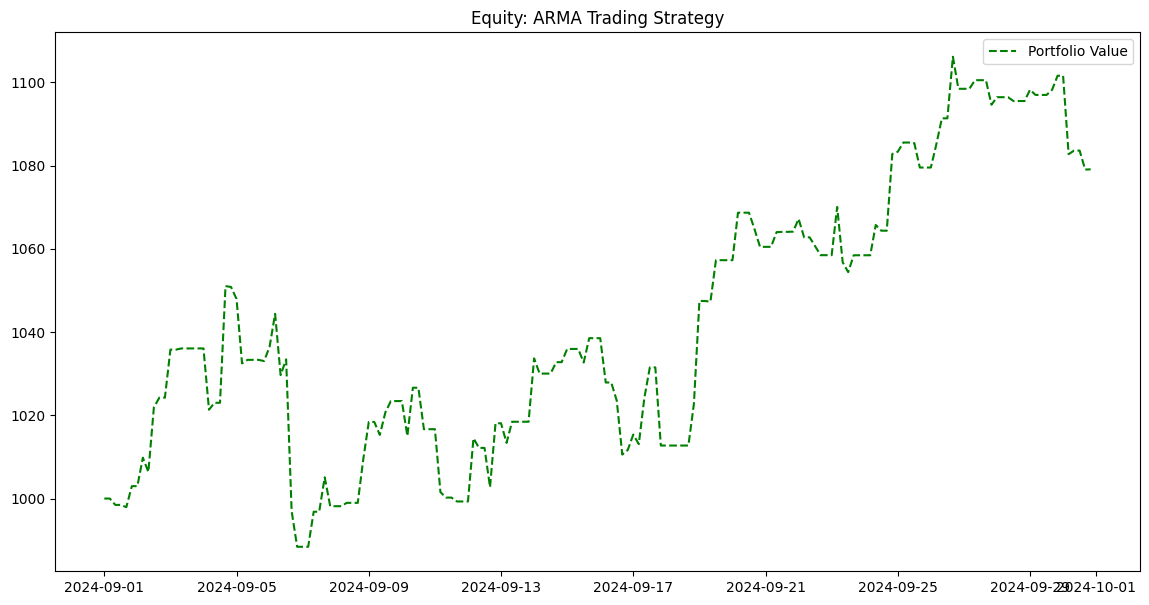

In [10]:
equities = {}
predictions = {}
for column in first_diff_df.columns:
    start = time()
    equity, prediction = backtest_arma(orders[column], all_data_df[column], pd.concat([first_diff_df_train[column], first_diff_df_test[column]]), first_diff_df_test[column], initial_capital=initial_capital)
    end = time()
    print("Total Time: ", end - start)
    equities[column] = equity
    predictions[column] = prediction
    plot_backtest(column, predictions, equities)
    break

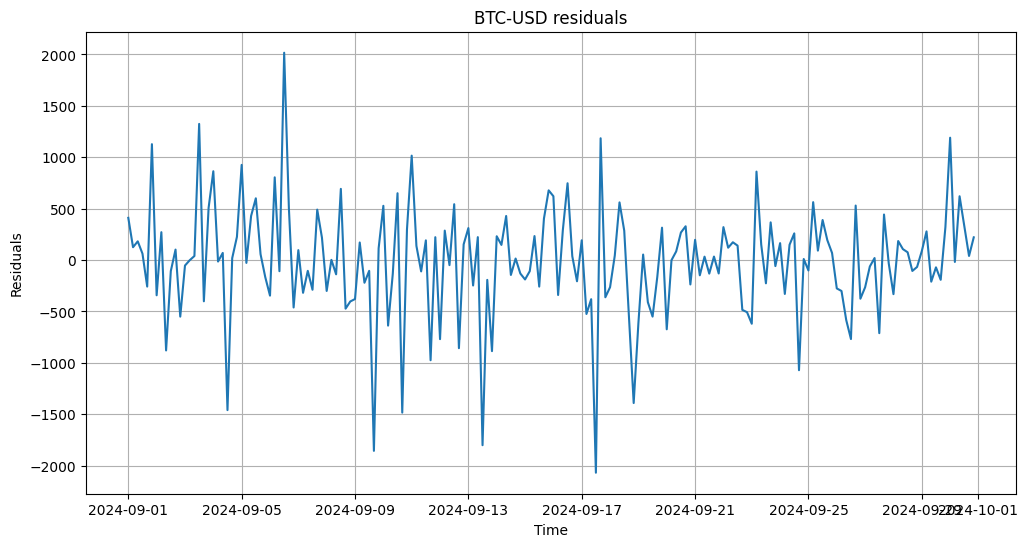

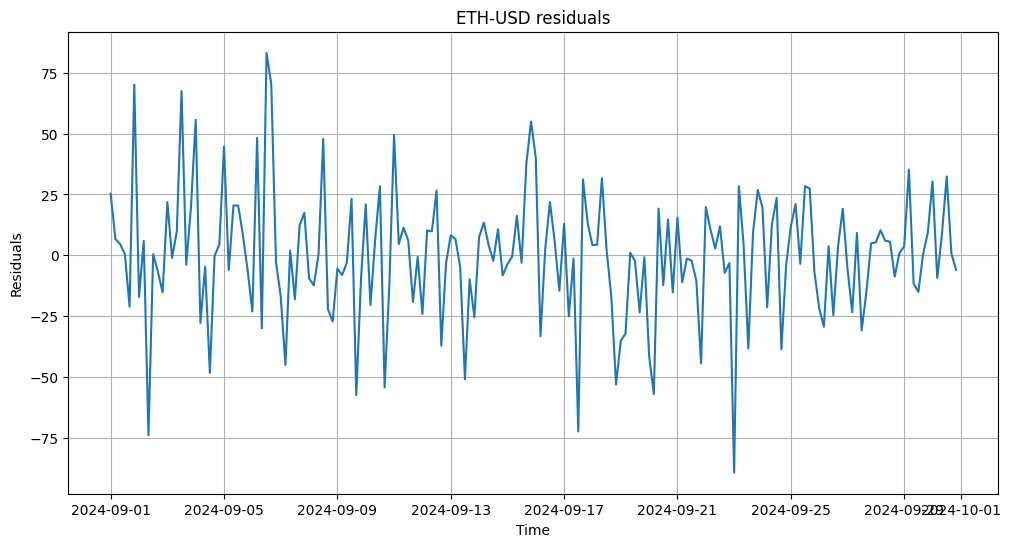

In [56]:
residuals = {}
for column in first_diff_df.columns:
    residuals[column] = predictions[column] - first_diff_df[column]
    residuals[column] = residuals[column].dropna()
    plt.figure(figsize=(12, 6))
    plt.plot(residuals[column])
    plt.title(f'{column} residuals')
    plt.xlabel('Time')
    plt.ylabel('Residuals')
    plt.grid(True)
    plt.show()

### ETH Here

<ipython-input-8-8452052f3ea9>:17: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  pred_v = pred[0]


equity:  1000.0


<ipython-input-8-8452052f3ea9>:17: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  pred_v = pred[0]


equity:  990.2830059813476


<ipython-input-8-8452052f3ea9>:17: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  pred_v = pred[0]


...

equity:  1092.5763271584735


<ipython-input-8-8452052f3ea9>:17: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  pred_v = pred[0]


equity:  1079.7195232311094


<ipython-input-8-8452052f3ea9>:17: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  pred_v = pred[0]
<ipython-input-8-8452052f3ea9>:31: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  print(f"Profit: {equity[-1] - equity[0]}")


equity:  1079.6958849245389
Profit: 79.69588492453886
Total Time:  664.730429649353


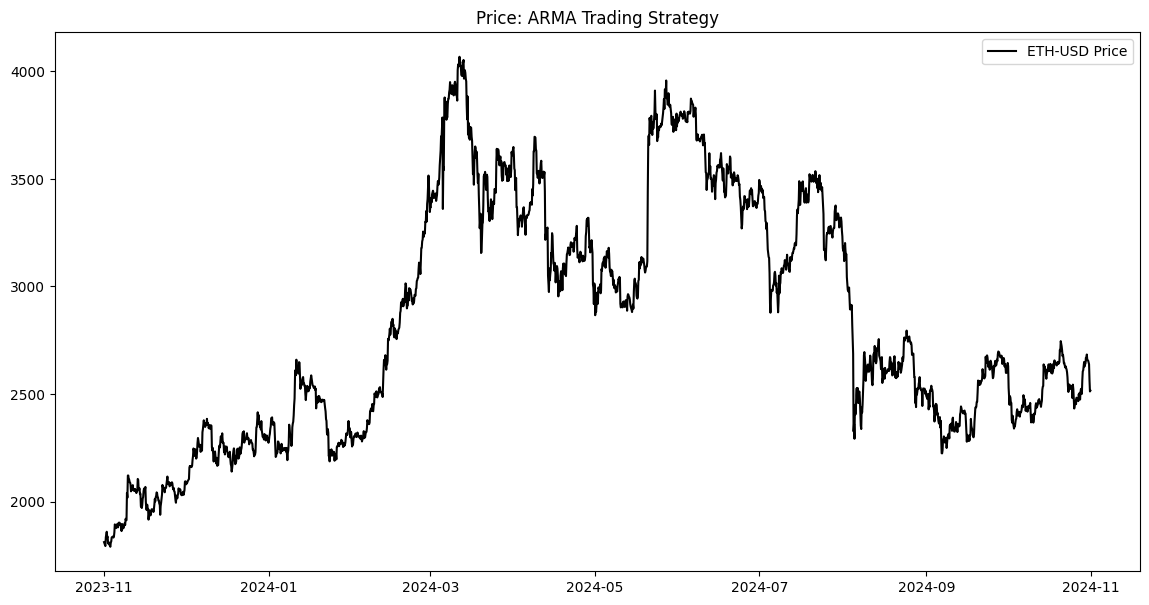

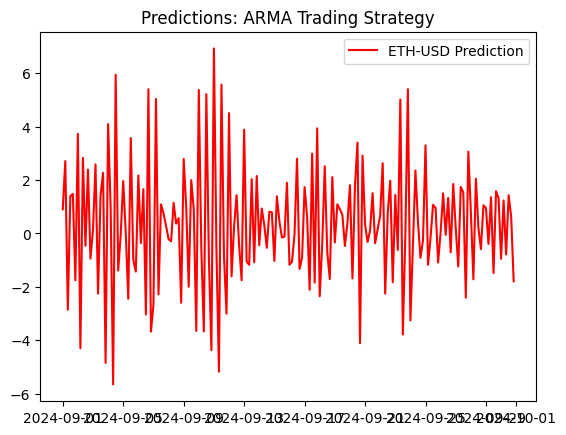

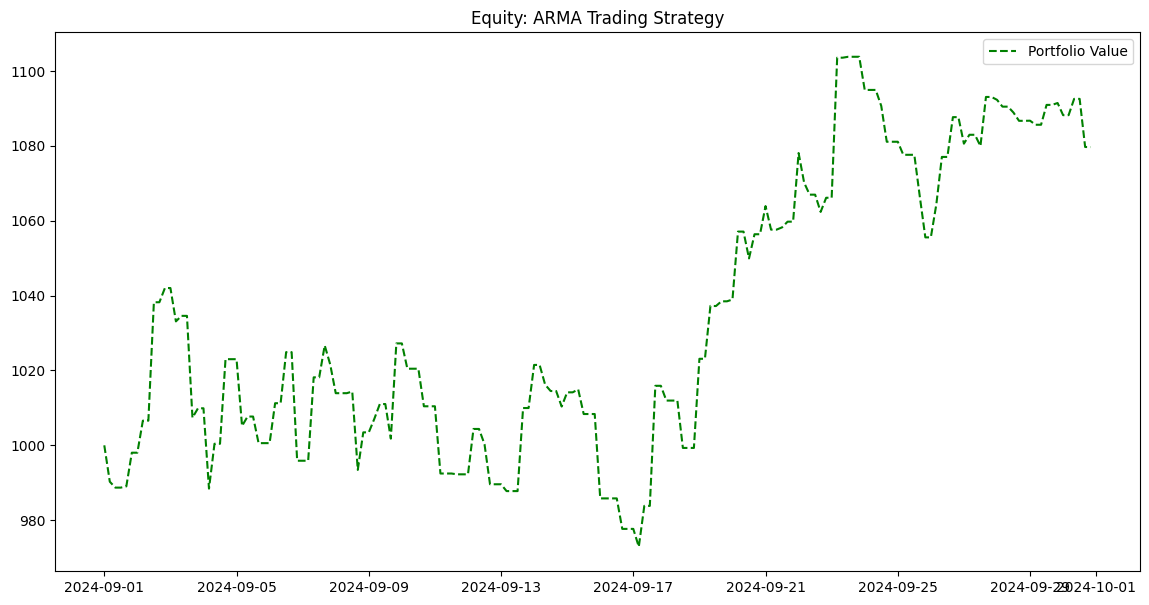

In [53]:
for column in first_diff_df.columns:
    column = 'ETH-USD'
    start = time()
    equity, prediction = backtest_arma(orders[column], all_data_df[column], pd.concat([first_diff_df_train[column], first_diff_df_test[column]]), first_diff_df_test[column], initial_capital=initial_capital)
    end = time()
    print("Total Time: ", end - start)
    equities[column] = equity
    predictions[column] = prediction
    plot_backtest(column, predictions, equities)
    break

### Residuals

In [57]:
for column in first_diff_df.columns:
    print(column)
    res = adfuller(residuals[column].dropna())
    print(f"ADF Statistics: {res[0]}\tP-value: {res[1]}")
    if res[1] < 0.1:
        print("Stationary")
    else:
        print("Not Stationary!")

BTC-USD
ADF Statistics: -14.247480742991396	P-value: 1.500807748094049e-26
Stationary
ETH-USD
ADF Statistics: -13.448135597297329	P-value: 3.729749665889019e-25
Stationary


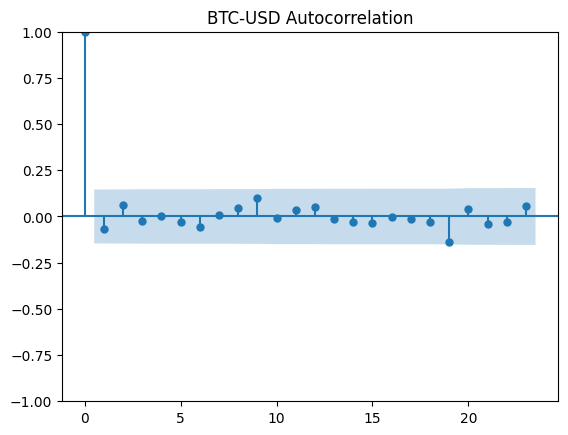

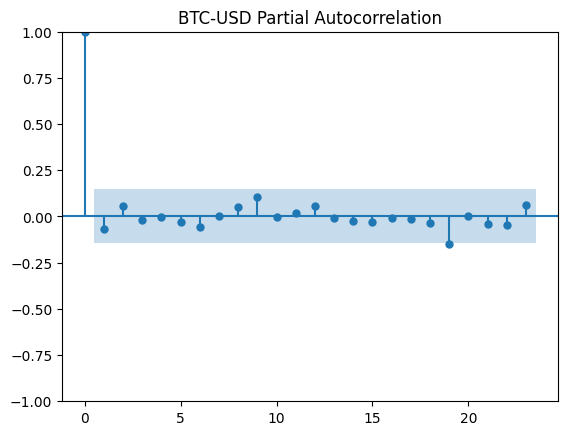

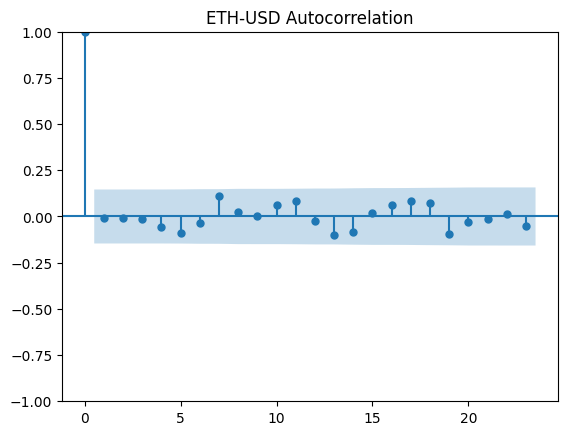

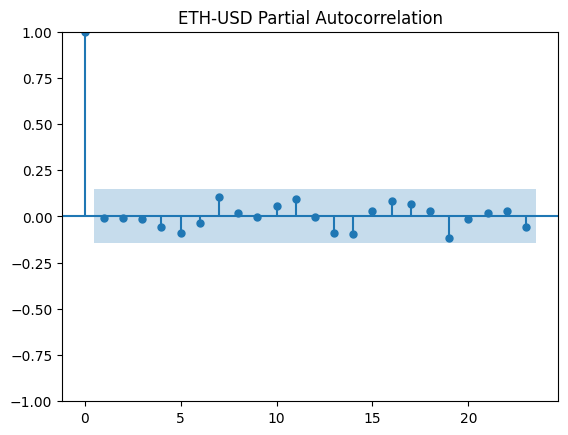

In [58]:
for column in first_diff_df.columns:
    plot_acf(residuals[column], title=f"{column} Autocorrelation")
    plot_pacf(residuals[column], title=f"{column} Partial Autocorrelation")

### Residuals First Difference

In [59]:
for column in first_diff_df.columns:
  residuals[column] = residuals[column].diff().dropna()

ADF Statistics: -9.119140210835456	P-value: 3.2407909666606202e-15
Stationary
ADF Statistics: -8.131196130622707	P-value: 1.0890937353675059e-12
Stationary


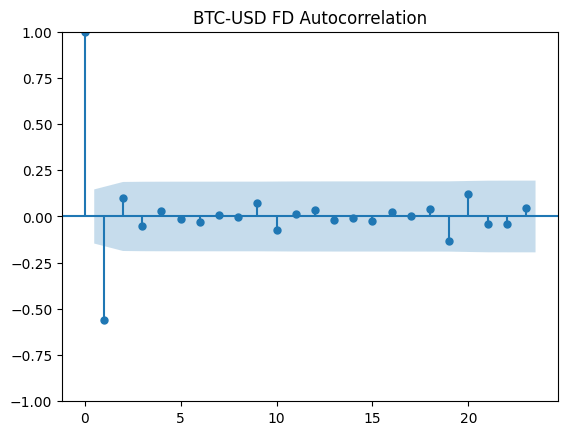

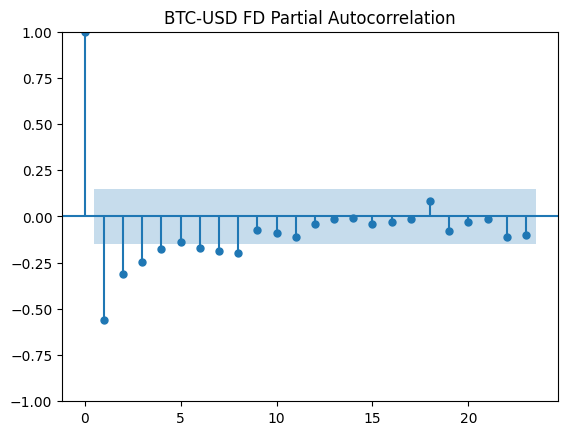

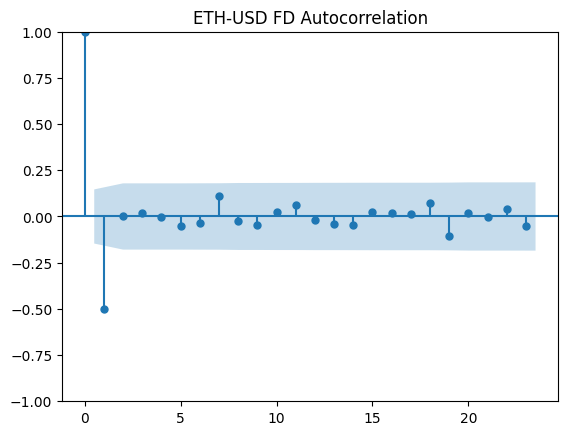

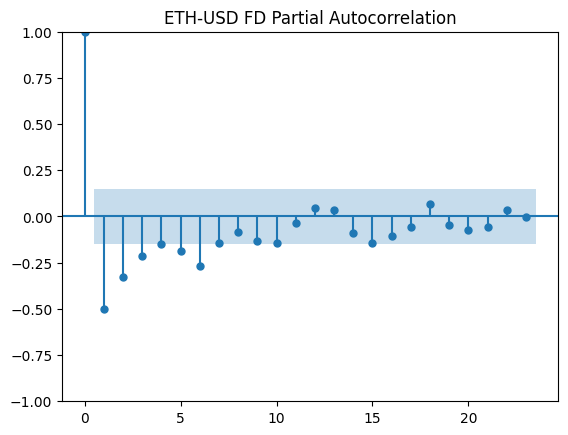

In [60]:
for column in first_diff_df.columns:
    res = adfuller(residuals[column])
    print(f"ADF Statistics: {res[0]}\tP-value: {res[1]}")
    if res[1] < 0.1:
        print("Stationary")
    plot_acf(residuals[column], title=f"{column} FD Autocorrelation")
    plot_pacf(residuals[column], title=f"{column} FD Partial Autocorrelation")

### Fit Arch & Garch Models

In [80]:
orders_arch = {'BTC-USD': (4, 0, 0), 'ETH-USD': (1, 0, 0)}

In [62]:
def backtest_arma_arch(order: tuple, prices:pd.DataFrame, train_data:pd.DataFrame, val_data:pd.DataFrame, initial_capital:float):
    Index = val_data.index
    equity = pd.Series(index=Index)
    predictions = pd.Series(index=Index)

    balance = initial_capital
    position = 0

    all_data = pd.concat([train_data, val_data])

    p, _, q = order

    for datetime in Index:
        model = arch_model(all_data[:datetime-timedelta(hours = 4)], p=p, q=q)
        model_fitted = model.fit(disp='off')
        pred = np.sqrt(model_fitted.forecast().variance.values[-1,:][0])
        predictions.loc[datetime] = pred

        if position == 0 and pred > 0:
            position = balance / prices[datetime-timedelta(hours = 4)]
            balance = 0

        elif position != 0 and pred < 0: 
            balance = position * prices[datetime-timedelta(hours = 4)]
            position = 0

        equity.loc[datetime] = balance + position * prices[datetime-timedelta(hours = 4)]
        

    print(f"Profit: {equity[-1] - equity[0]}")
    return equity, predictions


/usr/local/lib/python3.10/dist-packages/arch/univariate/base.py:309: DataScaleWarning: y is poorly scaled, which may affect convergence of the optimizer when
estimating the model parameters. The scale of y is 6.303e+05. Parameter
estimation work better when this value is between 1 and 1000. The recommended
rescaling is 0.1 * y.

This warning can be disabled by either rescaling y before initializing the
model or by setting rescale=False.

  warnings.warn(
/usr/local/lib/python3.10/dist-packages/arch/univariate/base.py:309: DataScaleWarning: y is poorly scaled, which may affect convergence of the optimizer when
estimating the model parameters. The scale of y is 6.275e+05. Parameter
estimation work better when this value is between 1 and 1000. The recommended
rescaling is 0.1 * y.

This warning can be disabled by either rescaling y before initializing the
model or by setting rescale=False.

  warnings.warn(
/usr/local/lib/python3.10/dist-packages/arch/univariate/base.py:309: DataScaleWarn

Profit: 108.02332485847671
Total Time:  10.5947425365448


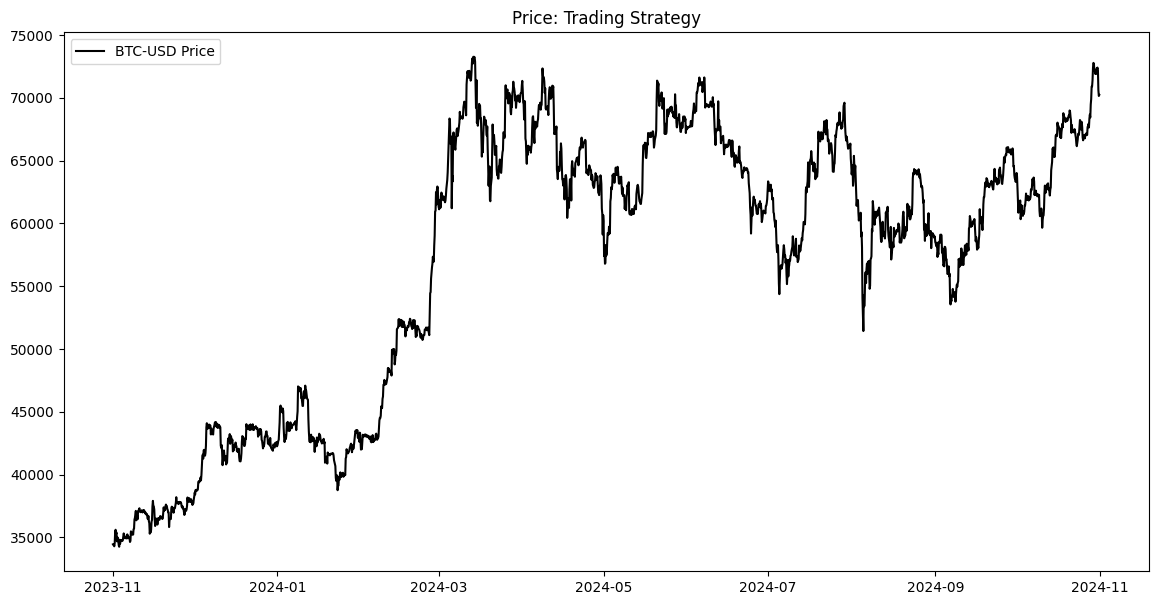

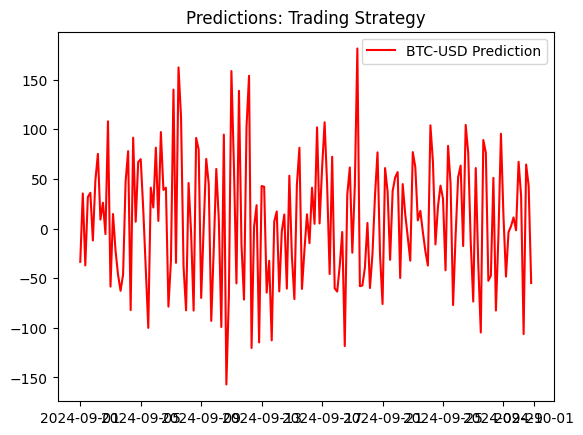

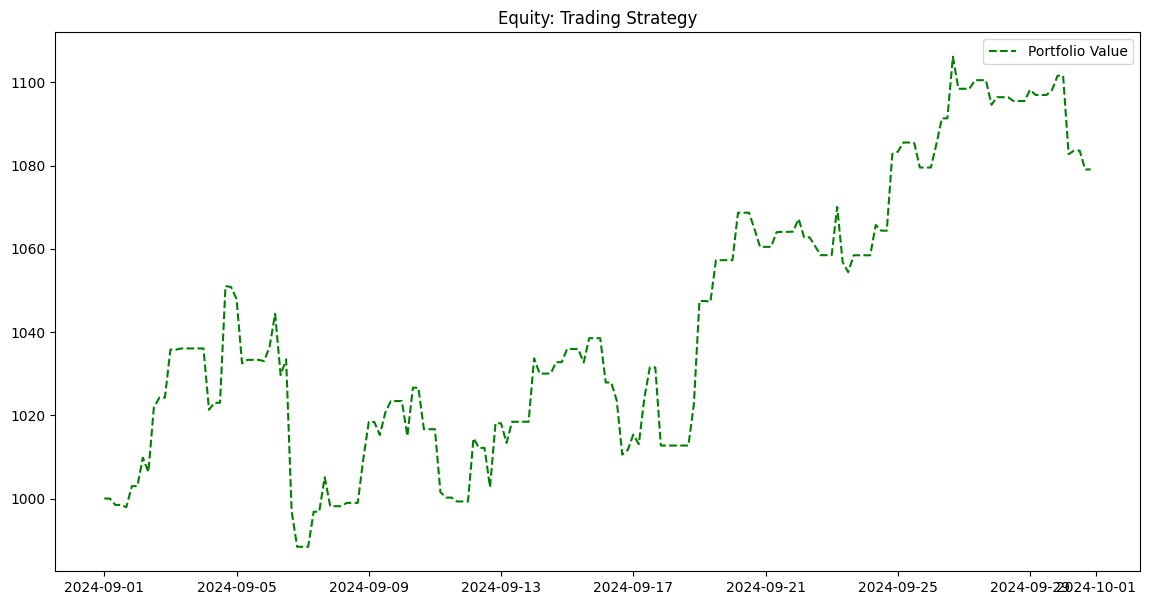

<ipython-input-62-d404dfad1e9a>:32: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  print(f"Profit: {equity[-1] - equity[0]}")


Profit: -34.78606504796312
Total Time:  7.28152060508728


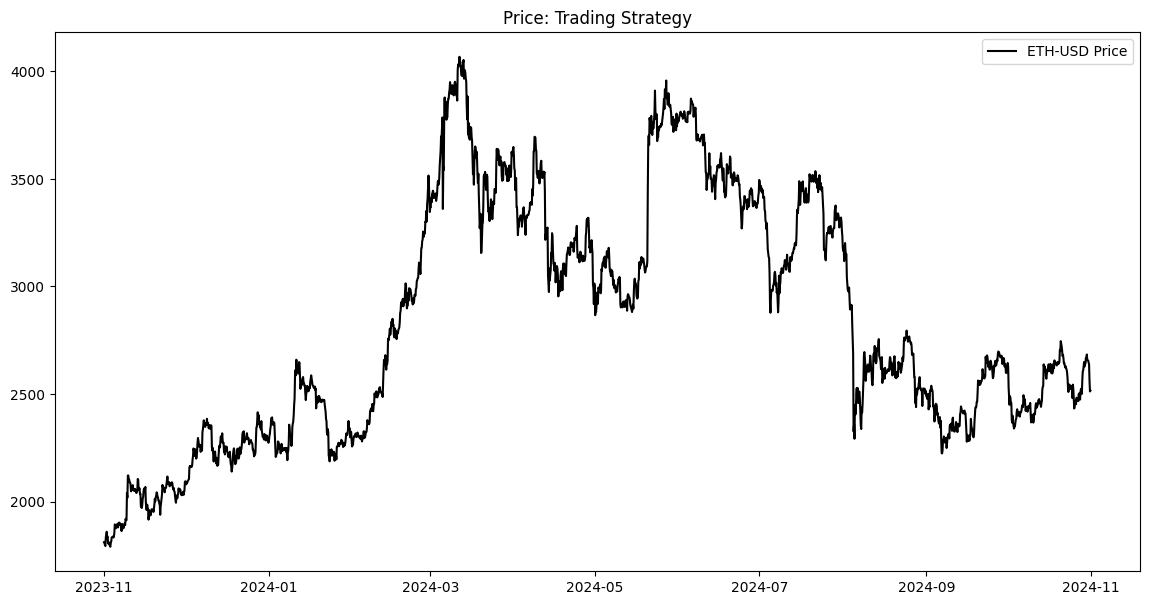

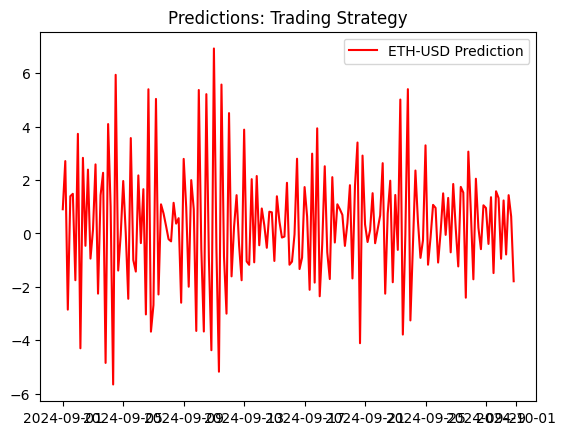

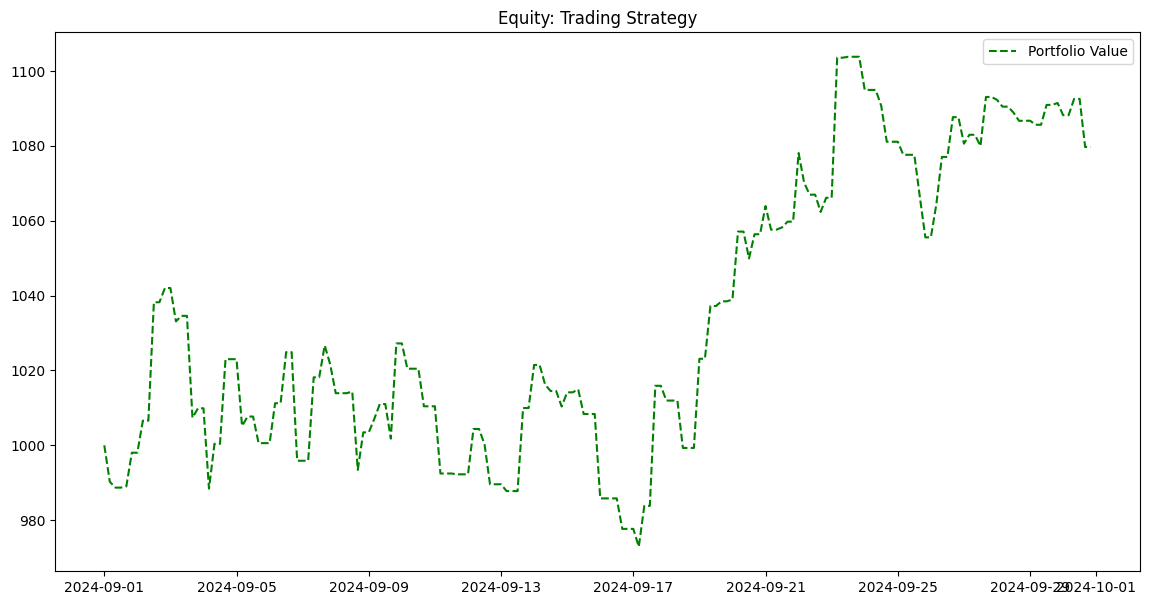

In [81]:
equities_arch = {}
predictions_arch = {}

for column in first_diff_df.columns:
    start = time()
    equity, prediction = backtest_arma_arch(orders_arch[column], all_data_df[column], residuals[column], first_diff_df_val[column], initial_capital=initial_capital)
    end = time()
    print("Total Time: ", end - start)
    equities_arch[column] = equity
    predictions_arch[column] = prediction
    plot_backtest(column, predictions, equities)

In [82]:
orders_garch = {
    'BTC-USD': (4, 0, 1),
    'ETH-USD': (1, 0, 1)
}

/usr/local/lib/python3.10/dist-packages/arch/univariate/base.py:309: DataScaleWarning: y is poorly scaled, which may affect convergence of the optimizer when
estimating the model parameters. The scale of y is 6.303e+05. Parameter
estimation work better when this value is between 1 and 1000. The recommended
rescaling is 0.1 * y.

This warning can be disabled by either rescaling y before initializing the
model or by setting rescale=False.

  warnings.warn(
/usr/local/lib/python3.10/dist-packages/arch/univariate/base.py:309: DataScaleWarning: y is poorly scaled, which may affect convergence of the optimizer when
estimating the model parameters. The scale of y is 6.275e+05. Parameter
estimation work better when this value is between 1 and 1000. The recommended
rescaling is 0.1 * y.

This warning can be disabled by either rescaling y before initializing the
model or by setting rescale=False.

  warnings.warn(
/usr/local/lib/python3.10/dist-packages/arch/univariate/base.py:309: DataScaleWarn

Profit: 108.02332485847671
Total Time:  12.748309135437012


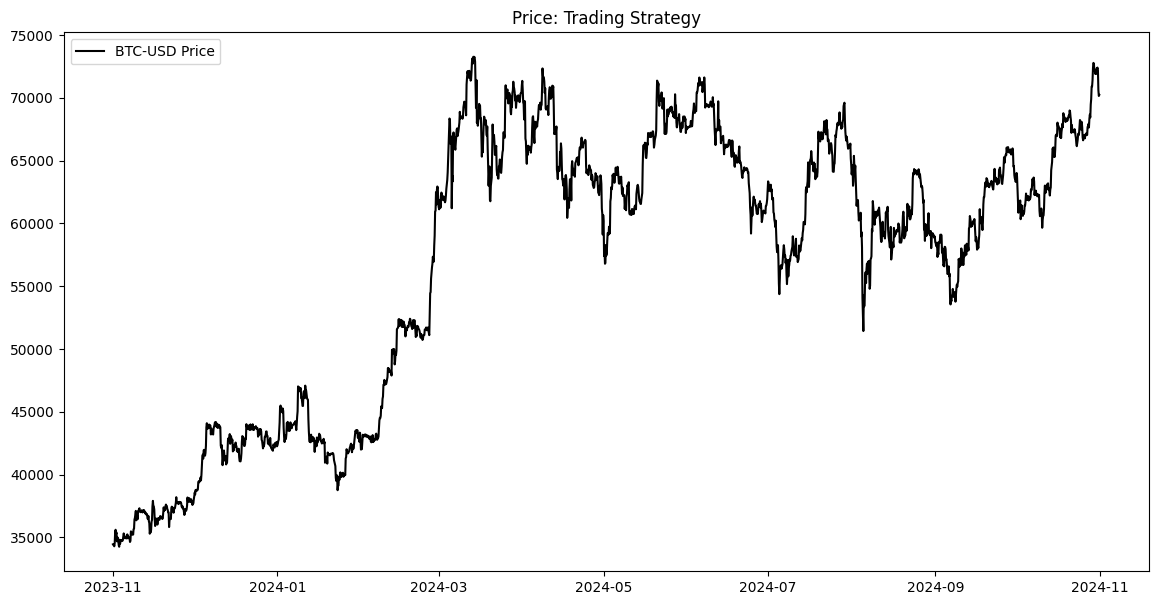

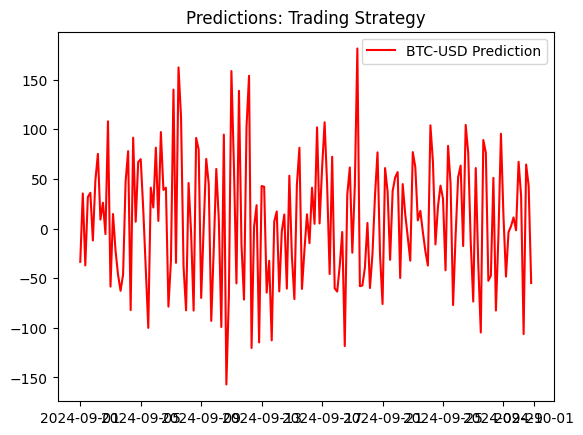

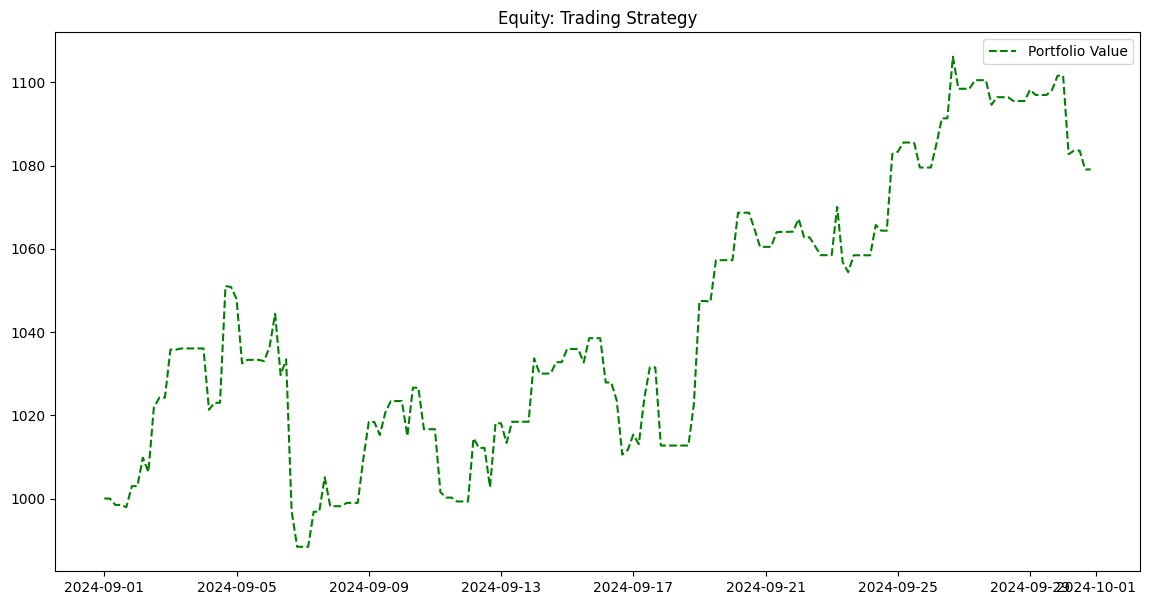

<ipython-input-62-d404dfad1e9a>:32: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  print(f"Profit: {equity[-1] - equity[0]}")


Profit: -34.78606504796312
Total Time:  7.291023015975952


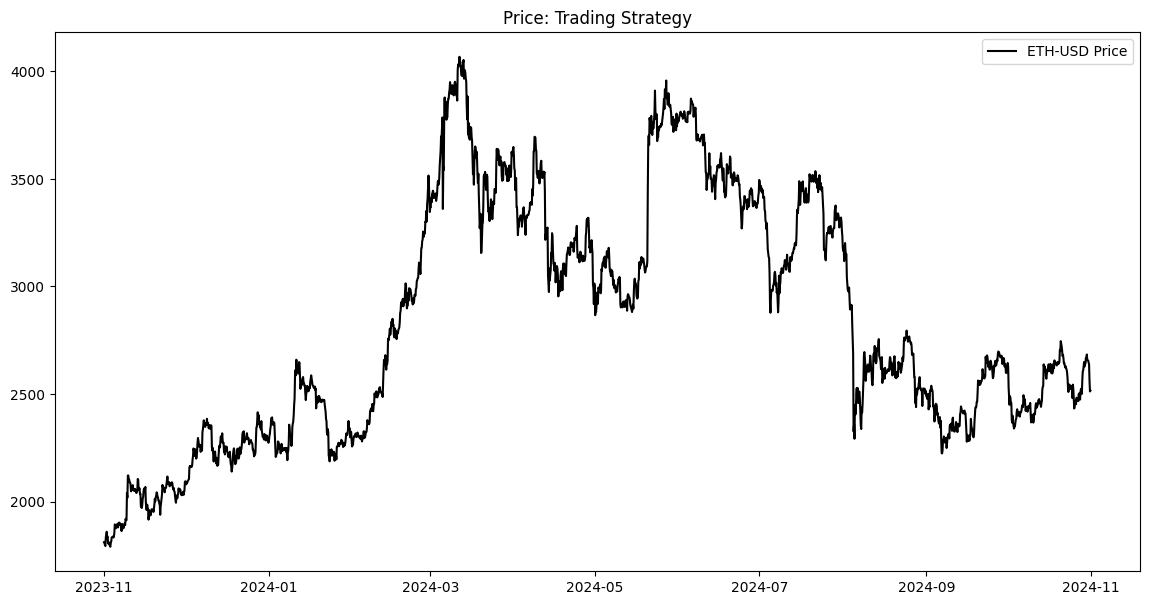

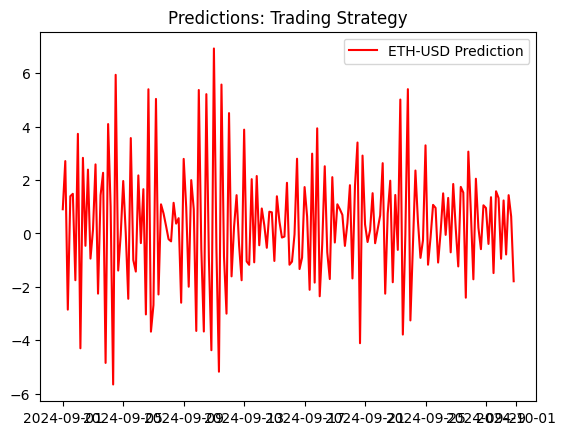

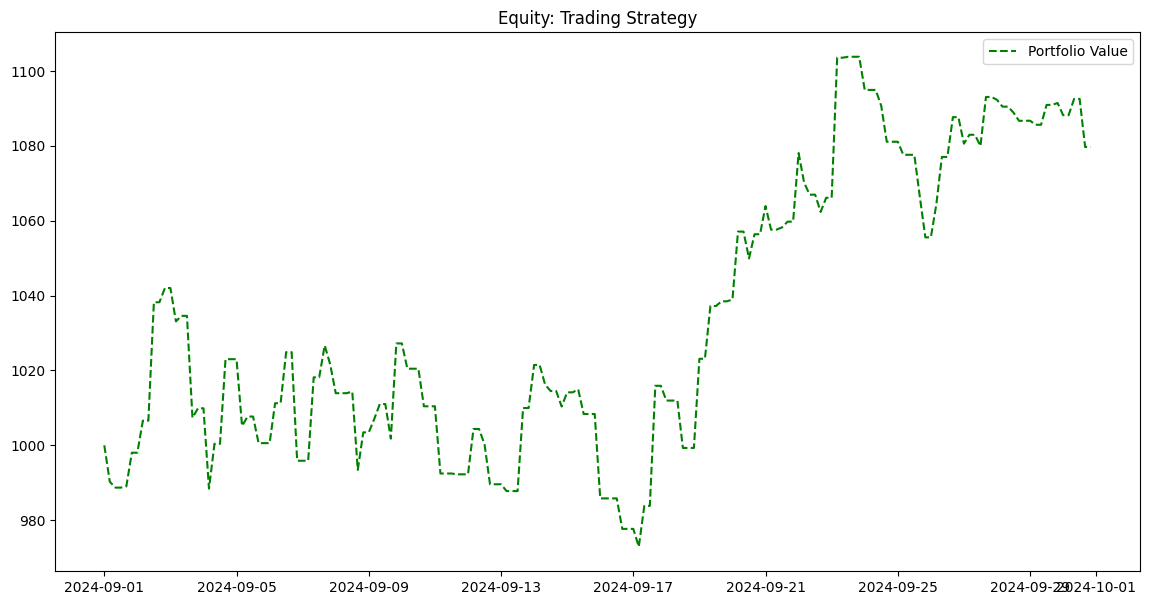

In [83]:
equities_garch = {}
predictions_garch = {}

for column in first_diff_df.columns:
    start = time()
    equity, prediction = backtest_arma_arch(orders_garch[column], all_data_df[column], residuals[column], first_diff_df_val[column], initial_capital=initial_capital)
    end = time()
    print("Total Time: ", end - start)
    equities_garch[column] = equity
    predictions_garch[column] = prediction
    plot_backtest(column, predictions, equities)

### Sharpes

In [71]:
def sharpe_ratio(equity: pd.Series, risk_free_rate=0.04) -> float:
    daily_returns = equity.pct_change().dropna()
    excess_returns = daily_returns - (risk_free_rate / 252)
    annualized_return = excess_returns.mean() * 252
    annualized_volatility = daily_returns.std() * np.sqrt(252)
    return annualized_return / annualized_volatility

In [84]:
print(sharpe_ratio(equities_org['BTC-USD']))
print(sharpe_ratio(equities_org['ETH-USD']))
print(sharpe_ratio(equities['BTC-USD']))
print(sharpe_ratio(equities['ETH-USD']))
print(sharpe_ratio(equities_arch['BTC-USD']))
print(sharpe_ratio(equities_arch['ETH-USD']))
print(sharpe_ratio(equities_garch['BTC-USD']))
print(sharpe_ratio(equities_garch['ETH-USD']))

-0.20475244657787395
0.2259880280270537
0.6791750785176501
0.55433826008914
0.8981789602162196
-0.47623809478153717
0.8981789602162196
-0.47623809478153717
